In [ ]:
import sys
import subprocess
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 日本語フォント設定
plt.rcParams["font.family"] = ["Meiryo", "Yu Gothic", "MS Gothic"]
plt.rcParams["axes.unicode_minus"] = False
import seaborn as sns

plt.style.use("bmh")

### 0. 全体の流れ（読み込み〜分析まで）


In [ ]:
df = pd.read_csv("spam.csv", encoding="latin-1")
df = df.iloc[:, :2].copy()
df.columns = ["label", "text"]

print(f"データ件数: {len(df)}")
print(df.head())

データ件数: 5572
  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


### 1. 前処理と特徴量づくり


In [ ]:
df["is_spam"] = df["label"].apply(lambda x: 1 if x == "spam" else 0)
df["length"] = df["text"].astype(str).apply(len)

df["has_digit"] = df["text"].astype(str).apply(
    lambda x: 1 if any(c.isdigit() for c in x) else 0
)

url_patterns = ["http", "www", ".com", ".net"]
df["has_url"] = df["text"].astype(str).apply(
    lambda x: 1 if any(p in x.lower() for p in url_patterns) else 0
)

df["has_exclam"] = df["text"].astype(str).apply(lambda x: 1 if "!" in x else 0)

money_words_free = ["free", "bonus"]
money_words_prize = ["win", "prize", "award"]
money_words_cash = ["cash", "money"]
money_words_claim = ["claim", "collect"]

df["has_money_free"] = df["text"].astype(str).apply(
    lambda x: 1 if any(w in x.lower() for w in money_words_free) else 0
)
df["has_money_prize"] = df["text"].astype(str).apply(
    lambda x: 1 if any(w in x.lower() for w in money_words_prize) else 0
)
df["has_money_cash"] = df["text"].astype(str).apply(
    lambda x: 1 if any(w in x.lower() for w in money_words_cash) else 0
)
df["has_money_claim"] = df["text"].astype(str).apply(
    lambda x: 1 if any(w in x.lower() for w in money_words_claim) else 0
)

df["has_money"] = (
    (df["has_money_free"] == 1)
    | (df["has_money_prize"] == 1)
    | (df["has_money_cash"] == 1)
    | (df["has_money_claim"] == 1)
).astype(int)

print("\n特徴量作成完了")
print(df[["label", "length", "has_digit", "has_url", "has_money", "has_exclam"]].head())



特徴量作成完了
  label  length  has_digit  has_url  has_money  has_exclam
0   ham     111          0        0          0           0
1   ham      29          0        0          0           0
2  spam     155          1        0          1           0
3   ham      49          0        0          0           0
4   ham      61          0        0          0           0


### 2. 記述統計と可視化



クラス内訳:
label
ham     4825
spam     747
Name: count, dtype: int64


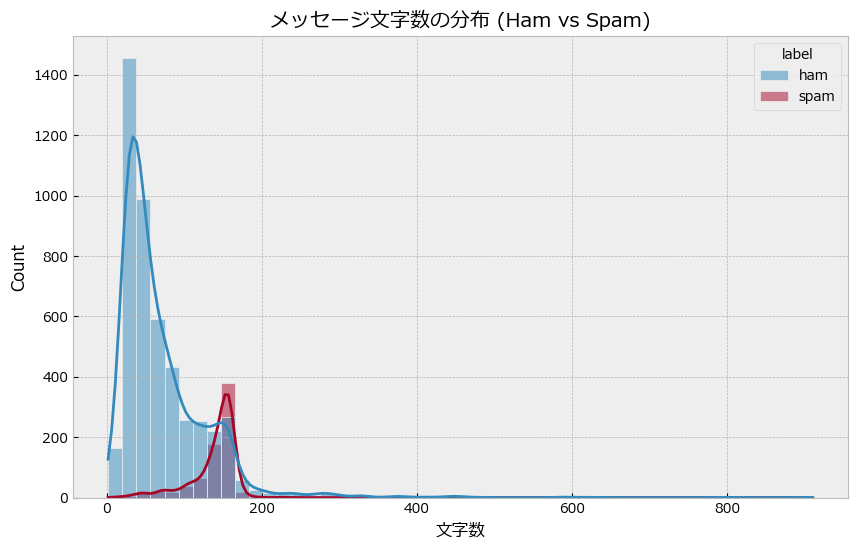


数字有無別のスパム率:
has_digit
0    0.009475
1    0.486264
Name: is_spam, dtype: float64

URL有無別のスパム率:
has_url
0    0.114733
1    0.873239
Name: is_spam, dtype: float64

金銭語カテゴリ別のスパム率:
free: {0: 0.09969731365872116, 1: 0.7692307692307693}
prize: {0: 0.10311027332704996, 1: 0.7490636704119851}
cash: {0: 0.12437902483900644, 1: 0.5182481751824818}
claim: {0: 0.10930275568707232, 1: 0.9454545454545454}


In [ ]:
print("\nクラス内訳:")
print(df["label"].value_counts())

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="length", hue="label", bins=50, kde=True)
plt.title("メッセージ文字数の分布 (Ham vs Spam)")
plt.xlabel("文字数")
plt.show()

print("\n数字有無別のスパム率:")
print(df.groupby("has_digit")["is_spam"].mean())

print("\nURL有無別のスパム率:")
print(df.groupby("has_url")["is_spam"].mean())

print("\n金銭語カテゴリ別のスパム率:")
print("free:", df.groupby("has_money_free")["is_spam"].mean().to_dict())
print("prize:", df.groupby("has_money_prize")["is_spam"].mean().to_dict())
print("cash:", df.groupby("has_money_cash")["is_spam"].mean().to_dict())
print("claim:", df.groupby("has_money_claim")["is_spam"].mean().to_dict())

### 3. ロジスティック回帰（ベースモデル）


In [ ]:
X = df[["length", "has_digit", "has_url", "has_money", "has_exclam"]]
y = df["is_spam"]

X = sm.add_constant(X)

model = sm.Logit(y, X)
result = model.fit()

print("\n=== ベースモデル結果 ===")
print(result.summary())

odds_ratios = np.exp(result.params)
print("\nオッズ比 (Odds Ratios):")
print(odds_ratios.sort_values(ascending=False))

X_money_detail = df[
    [
        "length",
        "has_digit",
        "has_url",
        "has_exclam",
        "has_money_free",
        "has_money_prize",
        "has_money_cash",
        "has_money_claim",
    ]
]
X_money_detail = sm.add_constant(X_money_detail)

model_money_detail = sm.Logit(y, X_money_detail)
result_money_detail = model_money_detail.fit()

print("\n=== 金銭語カテゴリ分解モデル結果 ===")
print(result_money_detail.summary())

odds_ratios_detail = np.exp(result_money_detail.params)
print("\nオッズ比（カテゴリ分解）:")
print(odds_ratios_detail.sort_values(ascending=False))

Optimization terminated successfully.
         Current function value: 0.135822
         Iterations 9

=== ベースモデル結果 ===
                           Logit Regression Results                           
Dep. Variable:                is_spam   No. Observations:                 5572
Model:                          Logit   Df Residuals:                     5566
Method:                           MLE   Df Model:                            5
Date:                Wed, 07 Jan 2026   Pseudo R-squ.:                  0.6553
Time:                        14:08:34   Log-Likelihood:                -756.80
converged:                       True   LL-Null:                       -2195.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.3547      0.236    -26.927      0.000      -6.817      -5.892
length     

### 5. 交差項モデル


In [ ]:
df["money_x_exclam"] = df["has_money"] * df["has_exclam"]

X_inter = df[["length", "has_digit", "has_url", "has_money", "has_exclam", "money_x_exclam"]]
X_inter = sm.add_constant(X_inter)

model_inter = sm.Logit(y, X_inter)
result_inter = model_inter.fit()

print("\n=== 交差項モデル結果 ===")
print(result_inter.summary())


Optimization terminated successfully.
         Current function value: 0.135388
         Iterations 9

=== 交差項モデル結果 ===
                           Logit Regression Results                           
Dep. Variable:                is_spam   No. Observations:                 5572
Model:                          Logit   Df Residuals:                     5565
Method:                           MLE   Df Model:                            6
Date:                Wed, 07 Jan 2026   Pseudo R-squ.:                  0.6564
Time:                        14:08:34   Log-Likelihood:                -754.38
converged:                       True   LL-Null:                       -2195.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -6.3809      0.243    -26.221      0.000      -6.858      -5.904

### 6. しきい値評価


In [ ]:
df["pred_prob"] = result.predict(X)

def evaluate_threshold(threshold):
    pred_label = (df["pred_prob"] >= threshold).astype(int)
    tp = ((df["is_spam"] == 1) & (pred_label == 1)).sum()
    tn = ((df["is_spam"] == 0) & (pred_label == 0)).sum()
    fp = ((df["is_spam"] == 0) & (pred_label == 1)).sum()
    fn = ((df["is_spam"] == 1) & (pred_label == 0)).sum()

    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0

    return {"threshold": threshold, "TP": tp, "TN": tn, "FP": fp, "FN": fn,
            "precision": precision, "recall": recall, "f1": f1}

threshold_results = pd.DataFrame([evaluate_threshold(t) for t in [0.3, 0.5, 0.7]])
print("\n=== しきい値別評価（ベースモデル） ===")
print(threshold_results)



=== しきい値別評価（ベースモデル） ===
   threshold   TP    TN   FP   FN  precision    recall        f1
0        0.3  588  4653  172  159   0.773684  0.787149  0.780358
1        0.5  572  4718  107  175   0.842415  0.765730  0.802244
2        0.7  474  4785   40  273   0.922179  0.634538  0.751784


### 7. 誤分類分析


In [ ]:
threshold_for_error_analysis = 0.5
df["pred_label"] = (df["pred_prob"] >= threshold_for_error_analysis).astype(int)

false_positive_cases = df[(df["is_spam"] == 0) & (df["pred_label"] == 1)].sort_values("pred_prob", ascending=False)
false_negative_cases = df[(df["is_spam"] == 1) & (df["pred_label"] == 0)].sort_values("pred_prob", ascending=True)

print(f"\n誤検知(False Positive)件数: {len(false_positive_cases)}")
print("誤検知サンプル（上位5件）:")
for text in false_positive_cases["text"].head(5):
    print("-", text)

print(f"\n見逃し(False Negative)件数: {len(false_negative_cases)}")
print("見逃しサンプル（上位5件）:")
for text in false_negative_cases["text"].head(5):
    print("-", text)


誤検知(False Positive)件数: 107
誤検知サンプル（上位5件）:
- \Si.como no?!listened2the plaid album-quite gd&the new air1 which is hilarious-also boughtåÓbraindanceåÓa comp.ofstuff on aphexåÕs ;abel
- Indians r poor but India is not a poor country. Says one of the swiss bank directors. He says that \ &lt;#&gt;  lac crore\" of Indian money is deposited in swiss banks which can be used for 'taxless' budget for  &lt;#&gt;  yrs. Can give  &lt;#&gt;  crore jobs to all Indians. From any village to Delhi 4 lane roads. Forever free power suply to more than  &lt;#&gt;  social projects. Every citizen can get monthly  &lt;#&gt; /- for  &lt;#&gt;  yrs. No need of World Bank &amp; IMF loan. Think how our money is blocked by rich politicians. We have full rights against corrupt politicians. Itna forward karo ki pura INDIA padhe.g.m.\""
- A Boy loved a gal. He propsd bt she didnt mind. He gv lv lttrs, Bt her frnds threw thm. Again d boy decided 2 aproach d gal , dt time a truck was speeding towards d gal. Wn it was a